# Visualisasi Evaluasi RAG

Notebook ini memvisualisasikan hasil evaluasi retrieval dan generasi untuk 3 metode chunking:
- Element-Based
- MaxMin Semantic
- Recursive

**Scope**: Top-5 hingga Top-10 saja (sesuai request user)

In [1]:
# Cell 1: Setup dan Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

# Config
TOPK_MIN = 5
TOPK_MAX = 10
DATA_DIR = Path("../results/final/generation")
FIG_DIR = Path("../results/final/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load data
dfs = []
for k in range(TOPK_MIN, TOPK_MAX + 1):
    pattern = f"eval_*_top{k}.csv"
    files = list(DATA_DIR.glob(pattern))
    if files:
        df = pd.read_csv(files[0])
        df['top_k'] = k
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Method name mapping
method_map = {
    'Element-Based': 'Element',
    'MaxMin Semantic': 'MaxMin',
    'Recursive': 'Recursive'
}
data['method_short'] = data['method'].map(method_map)

print(f"Loaded {len(data)} rows (top-{TOPK_MIN} to top-{TOPK_MAX})")
print(f"Methods: {data['method'].unique()}")

Loaded 540 rows (top-5 to top-10)
Methods: <ArrowStringArray>
['Element-Based', 'MaxMin Semantic', 'Recursive']
Length: 3, dtype: str


In [2]:
# Cell 2: Agregasi SEMUA data untuk visualisasi + Definisi fungsi highlight

# 1. Trend Recall & MRR (untuk Chart 1 & 2)
trend = data.groupby(['method_short', 'top_k'])[['recall_at_k', 'mrr']].mean().reset_index()

# 2. Generasi metrik (untuk Chart 3)
gen_avg = data[data['top_k'] == TOPK_MIN].groupby('method_short')[['bleu', 'rouge_l_recall']].mean().reset_index()

# 3. Hit count (untuk Chart 4)
hit_counts = []
for k in range(TOPK_MIN, TOPK_MAX + 1):
    for method in data['method_short'].unique():
        subset = data[(data['top_k'] == k) & (data['method_short'] == method)]
        n_hit = (subset['mrr'] > 0).sum()
        hit_counts.append({'method': method, 'top_k': k, 'hit_count': n_hit})
hit_df = pd.DataFrame(hit_counts)

# 4. Top-5 data
top5 = data[data['top_k'] == TOPK_MIN].copy()

# 5. Heatmap data (untuk Chart 5)
heatmap_data = top5.pivot_table(
    index='query_id',
    columns='method_short',
    values='mrr',
    aggfunc='mean'
).fillna(0)

# 6. Fungsi highlight untuk tabel (DEFINISI DI AWAL)
def highlight_max_only(s):
    """Highlight HANYA nilai max per row dengan warna subtle green + bold"""
    is_max = s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_max]

print("✓ Agregasi data selesai:")
print(f"  - trend: {len(trend)} rows")
print(f"  - gen_avg: {len(gen_avg)} rows")
print(f"  - hit_df: {len(hit_df)} rows")
print(f"  - top5: {len(top5)} rows")
print(f"  - heatmap_data: {heatmap_data.shape}")

✓ Agregasi data selesai:
  - trend: 18 rows
  - gen_avg: 3 rows
  - hit_df: 18 rows
  - top5: 90 rows
  - heatmap_data: (30, 3)


## Chart 1: Trend Recall@k vs Top-k

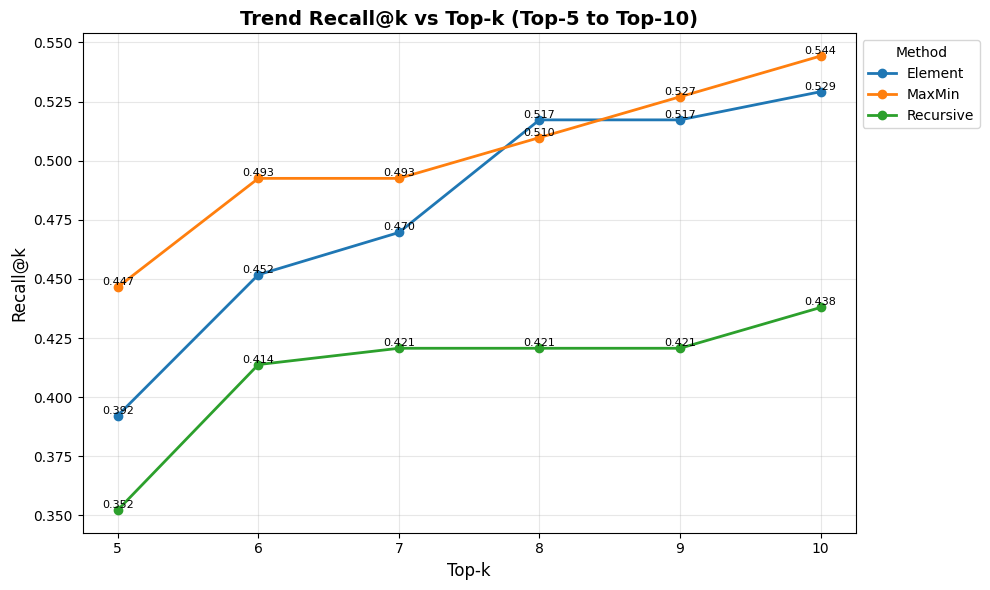

✓ Chart 1 saved

📊 Tabel 1: Recall@k per Metode dan Top-k


method_short,Element,MaxMin,Recursive
top_k,,,
5,0.3923,0.4466,0.3523
6,0.4518,0.4925,0.4138
7,0.4696,0.4925,0.4207
8,0.5173,0.5098,0.4207
9,0.5173,0.5270,0.4207
10,0.5292,0.5443,0.4379


✓ Table 1 exported


In [3]:
# Chart 1 + Tabel 1: Recall trend (DALAM SATU CELL)

# === CHART ===
plt.figure(figsize=(10, 6))
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    plt.plot(subset['top_k'], subset['recall_at_k'], marker='o', label=method, linewidth=2)

plt.xlabel('Top-k', fontsize=12)
plt.ylabel('Recall@k', fontsize=12)
plt.title('Trend Recall@k vs Top-k (Top-5 to Top-10)', fontsize=14, fontweight='bold')
plt.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)
plt.xticks(range(TOPK_MIN, TOPK_MAX + 1))
# Annotate values at each point
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    for _, row in subset.iterrows():
        plt.text(row['top_k'], row['recall_at_k'], f"{row['recall_at_k']:.3f}", 
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart1_recall_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 1 saved")

# === TABEL (TEPAT DI BAWAH CHART) ===
table1 = trend.pivot(index='top_k', columns='method_short', values='recall_at_k')
print("\n📊 Tabel 1: Recall@k per Metode dan Top-k")
styled_table1 = table1.style.format("{:.4f}").apply(highlight_max_only, axis=1)
display(styled_table1)

# Export CSV
table1.to_csv(FIG_DIR / 'table1_recall_trend.csv')
print(f"✓ Table 1 exported")

## Chart 2: Trend MRR vs Top-k

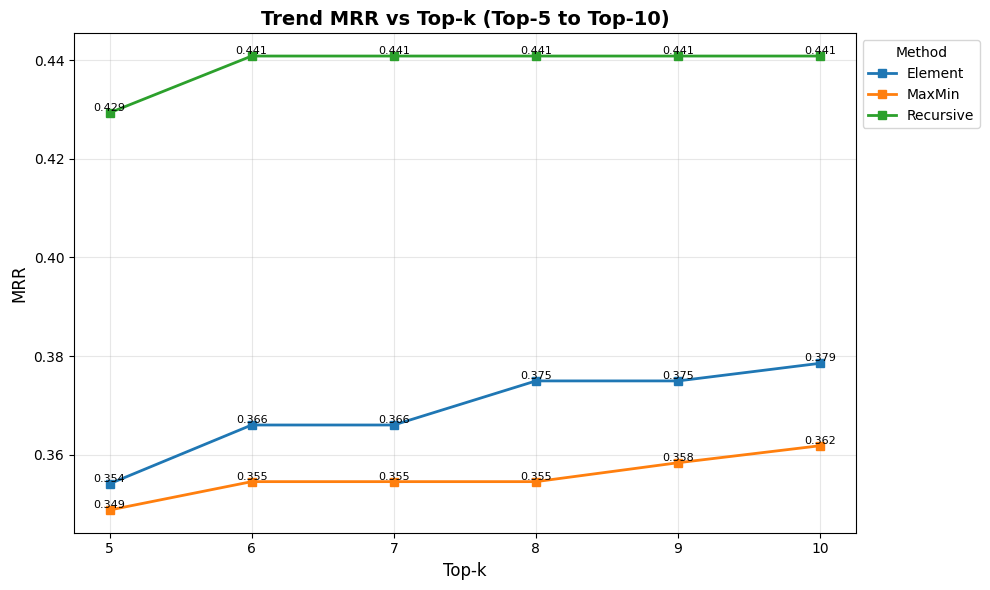

✓ Chart 2 saved

📊 Tabel 2: MRR per Metode dan Top-k


method_short,Element,MaxMin,Recursive
top_k,,,
5,0.3542,0.3488,0.4293
6,0.3661,0.3546,0.4408
7,0.3661,0.3546,0.4408
8,0.3750,0.3546,0.4408
9,0.3750,0.3584,0.4408
10,0.3786,0.3619,0.4408


✓ Table 2 exported


In [4]:
# Chart 2 + Tabel 2: MRR trend (DALAM SATU CELL)

# === CHART ===
plt.figure(figsize=(10, 6))
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    plt.plot(subset['top_k'], subset['mrr'], marker='s', label=method, linewidth=2)

plt.xlabel('Top-k', fontsize=12)
plt.ylabel('MRR', fontsize=12)
plt.title('Trend MRR vs Top-k (Top-5 to Top-10)', fontsize=14, fontweight='bold')
plt.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(alpha=0.3)
plt.xticks(range(TOPK_MIN, TOPK_MAX + 1))
# Annotate values at each point
for method in trend['method_short'].unique():
    subset = trend[trend['method_short'] == method]
    for _, row in subset.iterrows():
        plt.text(row['top_k'], row['mrr'], f"{row['mrr']:.3f}", 
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart2_mrr_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 2 saved")

# === TABEL (TEPAT DI BAWAH CHART) ===
table2 = trend.pivot(index='top_k', columns='method_short', values='mrr')
print("\n📊 Tabel 2: MRR per Metode dan Top-k")
styled_table2 = table2.style.format("{:.4f}").apply(highlight_max_only, axis=1)
display(styled_table2)

# Export CSV
table2.to_csv(FIG_DIR / 'table2_mrr_trend.csv')
print(f"✓ Table 2 exported")

## Chart 3: BLEU & ROUGE-L per Metode (Top-5)

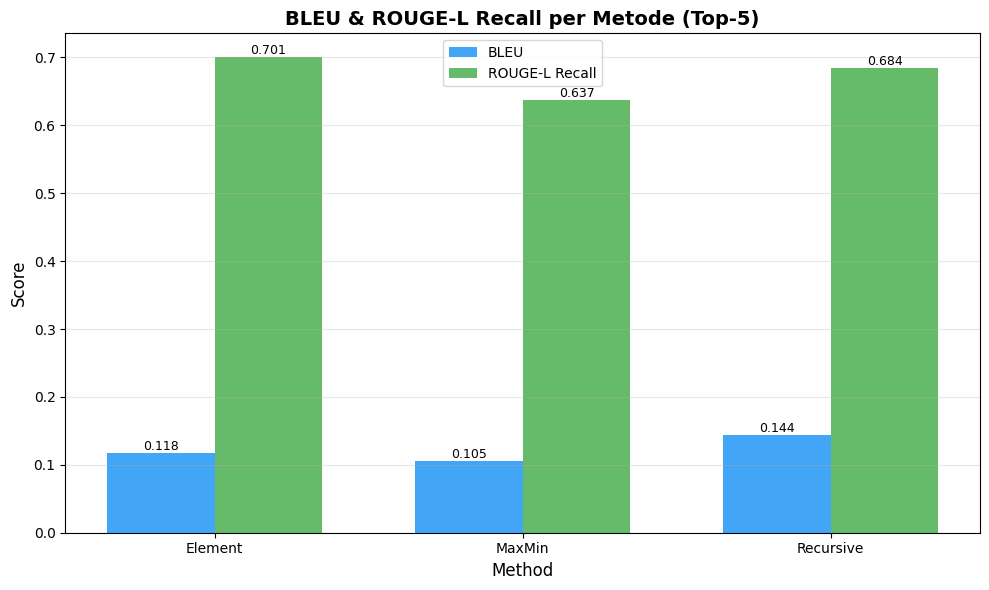

✓ Chart 3 saved

📊 Tabel 3: BLEU & ROUGE-L per Metode (Top-5)


,bleu,rouge_l_recall
method_short,,
Element,0.1178,0.7005
MaxMin,0.1052,0.6369
Recursive,0.1440,0.6838


✓ Table 3 exported


In [5]:
# Chart 3 + Tabel 3: Generasi metrik (DALAM SATU CELL)

# === CHART ===
x = np.arange(len(gen_avg))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, gen_avg['bleu'], width, label='BLEU', color='#42a5f5')
bars2 = ax.bar(x + width/2, gen_avg['rouge_l_recall'], width, label='ROUGE-L Recall', color='#66bb6a')

ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'BLEU & ROUGE-L Recall per Metode (Top-{TOPK_MIN})', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(gen_avg['method_short'])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Annotate values
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart3_generation_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 3 saved")

# === TABEL (TEPAT DI BAWAH CHART) ===
table3 = gen_avg.set_index('method_short')[['bleu', 'rouge_l_recall']]
print(f"\n📊 Tabel 3: BLEU & ROUGE-L per Metode (Top-{TOPK_MIN})")
styled_table3 = table3.style.format("{:.4f}").apply(highlight_max_only, axis=0)
display(styled_table3)

# Export CSV
table3.to_csv(FIG_DIR / 'table3_generation_metrics.csv')
print(f"✓ Table 3 exported")

## Chart 4: Jumlah Query Berhasil (MRR > 0) per Top-k

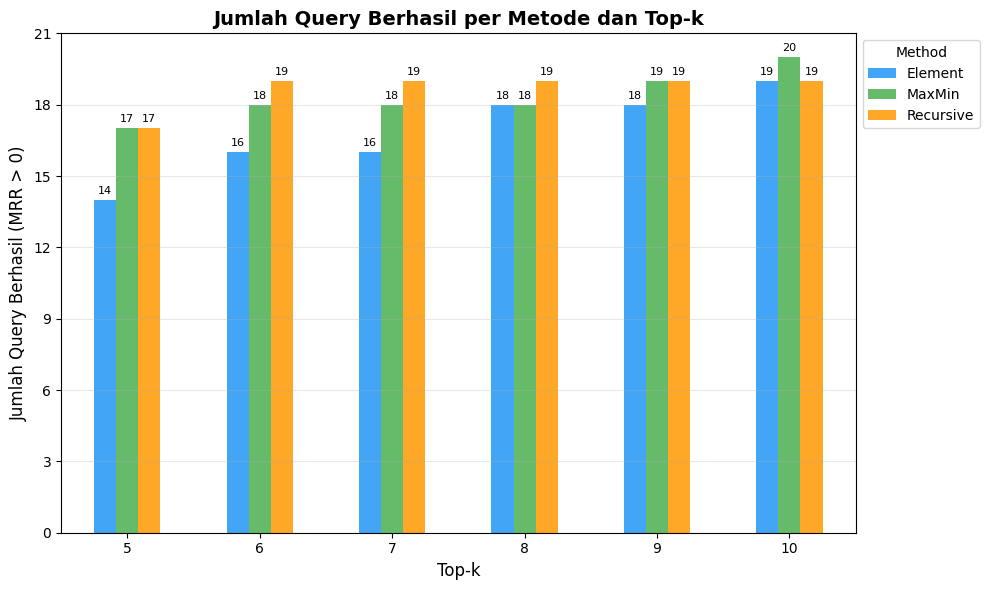

✓ Chart 4 saved

📊 Tabel 4: Jumlah Query Berhasil (MRR > 0) per Top-k


method,Element,MaxMin,Recursive
top_k,,,
5,14,17,17
6,16,18,19
7,16,18,19
8,18,18,19
9,18,19,19
10,19,20,19


✓ Table 4 exported


In [6]:
# Chart 4 + Tabel 4: Hit count (DALAM SATU CELL)

# === CHART ===
pivot_hit = hit_df.pivot(index='top_k', columns='method', values='hit_count')
pivot_hit.plot(kind='bar', figsize=(10, 6), color=['#42a5f5', '#66bb6a', '#ffa726'])

plt.xlabel('Top-k', fontsize=12)
plt.ylabel('Jumlah Query Berhasil (MRR > 0)', fontsize=12)
plt.title('Jumlah Query Berhasil per Metode dan Top-k', fontsize=14, fontweight='bold')
plt.legend(title='Method', fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
# Format Y-axis sebagai integer (bukan float)
from matplotlib.ticker import MaxNLocator
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True))

plt.grid(axis='y', alpha=0.3)
# Annotate values at top of each bar
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%d', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart4_hit_count.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 4 saved")

# === TABEL (TEPAT DI BAWAH CHART) ===
table4 = pivot_hit
print("\n📊 Tabel 4: Jumlah Query Berhasil (MRR > 0) per Top-k")
styled_table4 = table4.style.apply(highlight_max_only, axis=1)
display(styled_table4)

# Export CSV
table4.to_csv(FIG_DIR / 'table4_hit_count.csv')
print(f"✓ Table 4 exported")

## Chart 5: Heatmap MRR@5 per Query per Metode

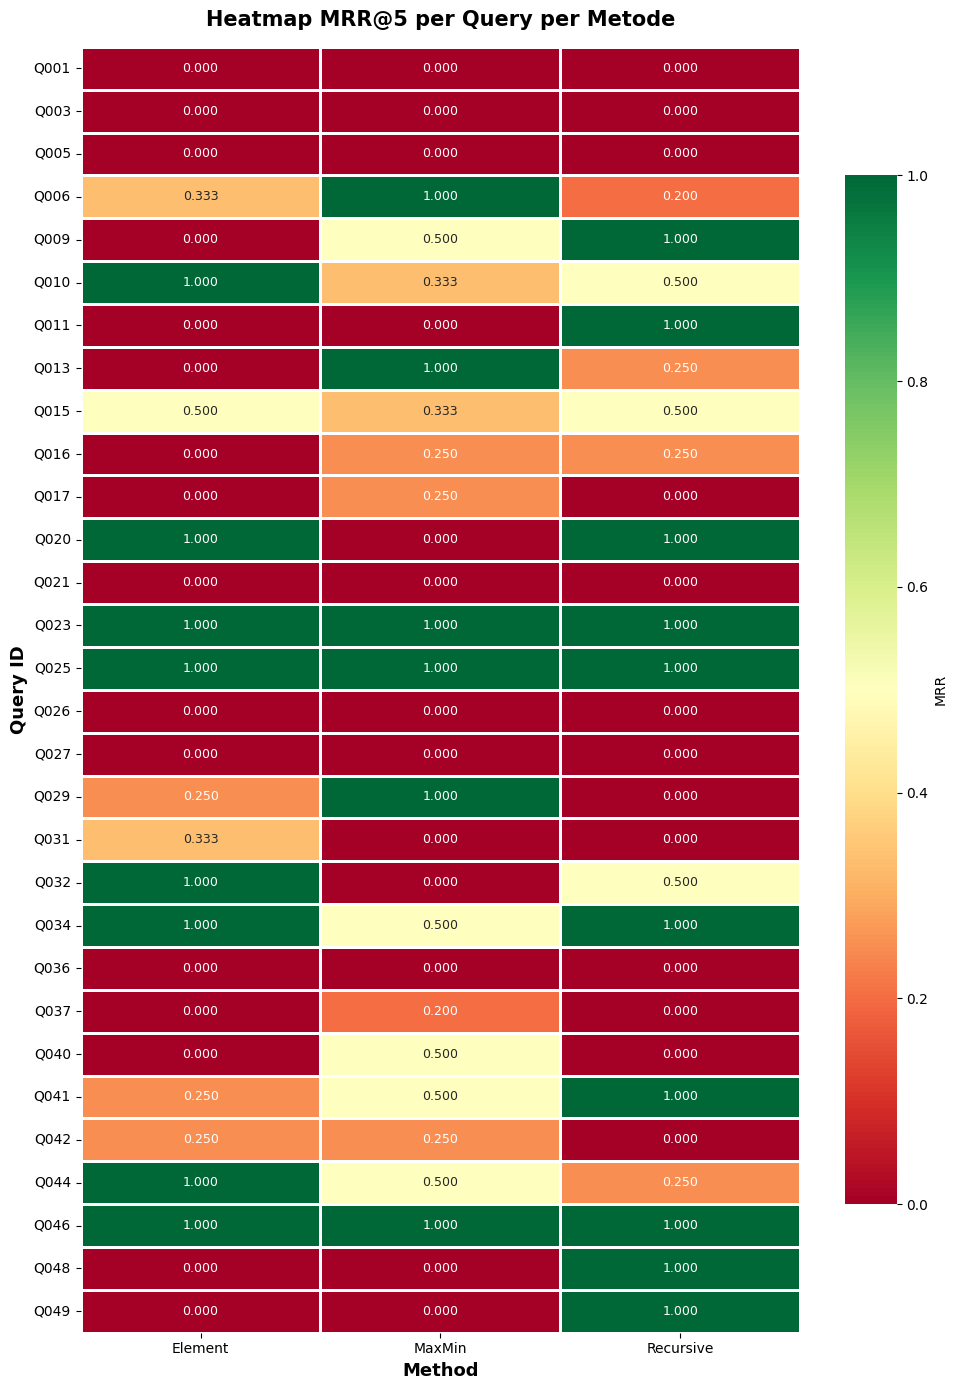

✓ Chart 5 saved

(Heatmap sudah menampilkan semua nilai numerik — tabel terpisah tidak diperlukan)


In [7]:
# Chart 5: Heatmap MRR per query (IMPROVED: lebih rapi, readable)
# Heatmap sudah menampilkan nilai numerik, tabel terpisah tidak diperlukan

fig, ax = plt.subplots(figsize=(10, 14))

# Heatmap dengan colormap lebih jelas dan annotations readable
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt=".3f",  # 3 decimal places untuk lebih rapi
            cmap="RdYlGn",  # Red-Yellow-Green: merah=buruk, hijau=bagus
            cbar_kws={'label': 'MRR', 'shrink': 0.8},
            linewidths=1,  # Border lebih tebal
            linecolor='white',  # Border putih, lebih jelas
            vmin=0, 
            vmax=1,
            annot_kws={'size': 9},  # Font annotation lebih besar
            square=False,  # Tidak square agar lebih compact
            ax=ax)

# Styling
ax.set_xlabel('Method', fontsize=13, fontweight='bold')
ax.set_ylabel('Query ID', fontsize=13, fontweight='bold')
ax.set_title(f'Heatmap MRR@{TOPK_MIN} per Query per Metode', fontsize=15, fontweight='bold', pad=15)

# Rotate labels untuk readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'chart5_heatmap_mrr.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Chart 5 saved")
print("\n(Heatmap sudah menampilkan semua nilai numerik — tabel terpisah tidak diperlukan)")

## Summary

Semua visualisasi dan tabel telah di-generate dan disimpan di `results/final/figures/`:
- **5 Chart PNG** (resolusi 300 DPI untuk laporan)
- **4 Tabel CSV** (untuk analisis numerik lanjutan)

Visualisasi mencakup top-5 hingga top-10 sesuai request user.

**Catatan**:
- Chart dan tabel berada dalam satu cell (tabel tepat di bawah chart)
- Radar chart dihapus sesuai request user
- Tabel styling: highlight HANYA nilai max dengan warna subtle (#d4edda) + bold
- Heatmap: lebih rapi, border putih, annotations readable